# Irregular Scenario – Fingerprint Method 2

**Scene:** Calle Esparteros (adjacent to Plaza Mayor) – a narrow, asymmetric street with 2 transmitters at z=5m. Strong NLOS conditions and multipath propagation.

**Method 2:** Fingerprint based on **5 features per TX**: channel gain, mean delay, RMS delay spread, strongest path delay, and strongest path gain. Position estimation uses kNN with z-score normalized Euclidean distance.

This scenario demonstrates the advantage of multipath-enhanced fingerprints under rich NLOS conditions (up to 40% error reduction vs Method 1).

## 1. Environment Setup
Install required dependencies.

In [2]:
# Celda 1: Instalar dependencias
!apt-get update
!apt-get install -y llvm
!pip install sionna-rt

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Hit:5 http://archive.ubuntu.com/ubuntu jammy-backports InRelease               
Hit:6 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Fetched 128 kB in 1s (212 kB/s)
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
llvm is already the newest version (1:14.0-55~exp2).
0 upgraded, 0 newly installed, 0 to remove and 114 not upgraded.


In [3]:
!pip uninstall sionna-rt -y
!pip install --upgrade pip

!pip install sionna-rt
!pip install scikit-learn


Found existing installation: sionna-rt 2.0.1
Uninstalling sionna-rt-2.0.1:
  Successfully uninstalled sionna-rt-2.0.1
  Using cached sionna_rt-2.0.1-py3-none-any.whl.metadata (4.8 kB)
Using cached sionna_rt-2.0.1-py3-none-any.whl (8.4 MB)


## 2. Library Imports
Import Sionna RT, NumPy, Matplotlib, and other required modules.

In [4]:
# después de reiniciar
import sionna.rt

# Other imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, KFold



no_preview = True # Toggle to False to use the preview widget

# Import relevant components from Sionna RT
from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

# (Aquí puedes continuar con el resto de tu código)
print("¡Sionna RT importado con éxito!")

¡Sionna RT importado con éxito!


## 3. Antenna Configuration
Define transmitter (TR38.901) and receiver (dipole, cross-polarized) antenna arrays.

In [5]:
# Configure antenna array for all transmitters
tx_array_config  = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="tr38901",  #tr38901
                             polarization="V")

# Configure antenna array for all receivers
rx_array_config = PlanarArray(num_rows=1,
                             num_cols=1,
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="dipole",  #dipole
                             polarization="cross") #cross

## 4. Path Solver Configuration
Set ray tracing parameters. The `max_depth` parameter is changed manually between executions to evaluate different NLOS conditions.

In [47]:
# Instantiate a path solver
# The same path solver can be used with multiple scenes
p_solver  = PathSolver()

# Compute propagation paths
solver_params = dict(
                 max_depth=10, #max numero de rebotes permitidos
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

## 5. Load 3D Scene
Import the Mitsuba/Sionna scene file.

In [48]:
scene= load_scene("Escena_Irregular_plazaMayor/Escena_Irregular_plazaMayor.xml", merge_shapes=True) # Merge shapes to speed-up computations

## 6. Transmitter Placement
Place transmitters at fixed positions in the irregular (Calle Esparteros) scenario.

In [49]:
scene.tx_array = tx_array_config
scene.rx_array = rx_array_config


np.random.seed(42) 

tx = Transmitter(name="tx",
                position=[-25, -5, 5],
                display_radius=1)
tx1 = Transmitter(name="tx1",
                 position=[-30, -30, 5],
                 display_radius=1)
tx2 = Transmitter(name="tx2",
                position=[40, 10, 10],
                display_radius=1)


# [18, -37, 26]


scene.add(tx)
scene.add(tx1)
#scene.add(tx2)



### RECEPTORES GRID SEARCH

## 7. Training Grid (Reference Receivers)
Create a uniform grid of receivers spaced 3m apart for the fingerprint database.

In [50]:
import numpy as np
import mitsuba as mi
from sionna.rt import Receiver
np.random.seed(42) 
# =======================================
# Rejilla 3D con SOLO 2 niveles en Z
# =======================================
def crear_rejilla_2_niveles_z(
    scene,
    x_lim,
    y_lim,
    z_levels,
    paso_xy,
    nombre_base="rx"
):
    # Coordenadas X, Y uniformes
    x_coords = np.arange(x_lim[0], x_lim[1] + paso_xy, paso_xy)
    
    if y_lim[0] < y_lim[1]:
        y_coords = np.arange(y_lim[0], y_lim[1] + paso_xy, paso_xy)
    else:
        y_coords = np.arange(y_lim[0], y_lim[1] - paso_xy, -paso_xy)


    receptores = []
    idx = 0

    for z in z_levels:
        for x in x_coords:
            for y in y_coords:
                pos = mi.Point3f(float(x), float(y), float(z))
                rx = Receiver(
                    name=f"{nombre_base}_{idx}",
                    position=pos,
                    display_radius=0.5
                )
                scene.add(rx)
                receptores.append(rx)
                idx += 1

    return receptores

# =======================================
# Definición del espacio
# =======================================
x_lim = [-40, -10]
y_lim = [10, -40]

# SOLO DOS NIVELES EN Z
z_levels = [1.5]

paso_xy = 3.0  # separación en X e Y (metros)

# Crear receptores
receptores_grid = crear_rejilla_2_niveles_z(
    scene,
    x_lim,
    y_lim,
    z_levels,
    paso_xy,
    nombre_base="rx_grid"
)

print(f"\n✔ Receptores creados: {len(receptores_grid)}")

print("\nEjemplo de receptores:") 
for i, rx in enumerate(receptores_grid[:]):
    x, y, z = [rx.position[j].numpy().item() for j in range(3)] 
    print(f"R{i:03d}: ({x:.1f}, {y:.1f}, {z:.1f})")



✔ Receptores creados: 198

Ejemplo de receptores:
R000: (-40.0, 10.0, 1.5)
R001: (-40.0, 7.0, 1.5)
R002: (-40.0, 4.0, 1.5)
R003: (-40.0, 1.0, 1.5)
R004: (-40.0, -2.0, 1.5)
R005: (-40.0, -5.0, 1.5)
R006: (-40.0, -8.0, 1.5)
R007: (-40.0, -11.0, 1.5)
R008: (-40.0, -14.0, 1.5)
R009: (-40.0, -17.0, 1.5)
R010: (-40.0, -20.0, 1.5)
R011: (-40.0, -23.0, 1.5)
R012: (-40.0, -26.0, 1.5)
R013: (-40.0, -29.0, 1.5)
R014: (-40.0, -32.0, 1.5)
R015: (-40.0, -35.0, 1.5)
R016: (-40.0, -38.0, 1.5)
R017: (-40.0, -41.0, 1.5)
R018: (-37.0, 10.0, 1.5)
R019: (-37.0, 7.0, 1.5)
R020: (-37.0, 4.0, 1.5)
R021: (-37.0, 1.0, 1.5)
R022: (-37.0, -2.0, 1.5)
R023: (-37.0, -5.0, 1.5)
R024: (-37.0, -8.0, 1.5)
R025: (-37.0, -11.0, 1.5)
R026: (-37.0, -14.0, 1.5)
R027: (-37.0, -17.0, 1.5)
R028: (-37.0, -20.0, 1.5)
R029: (-37.0, -23.0, 1.5)
R030: (-37.0, -26.0, 1.5)
R031: (-37.0, -29.0, 1.5)
R032: (-37.0, -32.0, 1.5)
R033: (-37.0, -35.0, 1.5)
R034: (-37.0, -38.0, 1.5)
R035: (-37.0, -41.0, 1.5)
R036: (-34.0, 10.0, 1.5)
R037: (-

### RECEPTORES TESTING

## 8. Test Receivers (Unknown Positions)
100 receivers at random positions. Their locations will be estimated.

In [51]:
import numpy as np
import mitsuba as mi
from sionna.rt import Receiver

np.random.seed(123)

num_test_rx = 100
receptores_test = []

for i in range(num_test_rx):
    x = np.random.uniform(x_lim[0], x_lim[1])
    y = np.random.uniform(y_lim[0], y_lim[1])
    z = 1.5

    rx = Receiver(
        name=f"rx_test_{i}",
        position=mi.Point3f(float(x), float(y), float(z)),
        display_radius=0.5
    )
    scene.add(rx)
    receptores_test.append(rx)

print(f"\n✔ Receptores a estimar test creados: {len(receptores_test)}")

print("\nEjemplo de receptores:") 
for i, rx in enumerate(receptores_test[:]):
    x, y, z = [rx.position[j].numpy().item() for j in range(3)] 
    print(f"R{i:03d}: ({x:.1f}, {y:.1f}, {z:.1f})")


✔ Receptores a estimar test creados: 100

Ejemplo de receptores:
R000: (-19.1, -4.3, 1.5)
R001: (-33.2, -17.6, 1.5)
R002: (-18.4, -11.2, 1.5)
R003: (-10.6, -24.2, 1.5)
R004: (-25.6, -9.6, 1.5)
R005: (-29.7, -26.5, 1.5)
R006: (-26.8, 7.0, 1.5)
R007: (-28.1, -26.9, 1.5)
R008: (-34.5, 1.2, 1.5)
R009: (-24.1, -16.6, 1.5)
R010: (-21.0, -32.5, 1.5)
R011: (-18.3, -20.6, 1.5)
R012: (-18.3, -6.1, 1.5)
R013: (-29.1, -1.4, 1.5)
R014: (-31.2, -21.5, 1.5)
R015: (-37.2, -11.7, 1.5)
R016: (-27.1, -14.7, 1.5)
R017: (-27.2, -5.6, 1.5)
R018: (-27.2, -34.7, 1.5)
R019: (-11.7, -15.1, 1.5)
R020: (-21.3, 4.2, 1.5)
R021: (-30.5, -10.7, 1.5)
R022: (-14.0, -2.5, 1.5)
R023: (-25.5, -39.3, 1.5)
R024: (-24.4, -20.6, 1.5)
R025: (-36.4, -31.3, 1.5)
R026: (-21.9, -17.3, 1.5)
R027: (-29.7, -5.2, 1.5)
R028: (-27.5, -24.1, 1.5)
R029: (-13.7, -15.5, 1.5)
R030: (-19.9, -19.3, 1.5)
R031: (-21.3, -23.7, 1.5)
R032: (-14.7, 5.8, 1.5)
R033: (-17.1, -2.2, 1.5)
R034: (-34.2, -18.6, 1.5)
R035: (-37.1, -34.3, 1.5)
R036: (-21.2, 

### FINGERPRINT TRAINING

## 9. Run Ray Tracing
Compute all propagation paths.

In [52]:
paths_scene_caso1 = p_solver(scene=scene, **solver_params)

## 10. Extract Channel Impulse Response (CIR)
Obtain channel coefficients and path delays.

In [53]:



#CIR 
#CASO 1
a_c1, tau_c1 = paths_scene_caso1.cir(normalize_delays=True, out_type="numpy")

# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths, num_time_steps]
print("Shape of a: ", a_c1.shape)
num_paths_c1 = a_c1.shape[4]
print("Num of possible paths from tx to rx: ", num_paths_c1)
# Shape: [num_rx, num_rx_ant, num_tx, num_tx_ant, num_paths]
print("Shape of tau: ", tau_c1.shape)





Shape of a:  (298, 2, 2, 1, 150, 1)
Num of possible paths from tx to rx:  150
Shape of tau:  (298, 2, 2, 1, 150)


## 11. Generate Training Fingerprints (Method 2)
For each grid receiver and each TX, extract 5 features:
- Channel gain (dB)
- Mean delay
- RMS delay spread
- Strongest path delay
- Strongest path gain

In [54]:
fingerprints_grid = []
positions_grid = []

for rx_index, rx in enumerate(receptores_grid):
  fp_rx = []

  for tx_index in range(a_c1.shape[2]):
      a_rt = a_c1[rx_index, 0, tx_index, 0, :, 0]
      tau_rt = tau_c1[rx_index, 0, tx_index, 0, :]

      power = np.abs(a_rt)**2
      total_power = np.sum(power) + 1e-12

      channel_gain = 10 * np.log10(total_power)
      mean_delay = np.sum(power * tau_rt) / total_power
      rms_delay = np.sqrt(np.sum(power * (tau_rt - mean_delay)**2) / total_power)
      strongest_idx = np.argmax(power)
      tau_max = tau_rt[strongest_idx]
      g_max = 10 * np.log10(power[strongest_idx] + 1e-12)

      fp_rx.extend([channel_gain, mean_delay, rms_delay, tau_max, g_max])

  fingerprints_grid.append(fp_rx)
  positions_grid.append(np.array(rx.position))

fingerprints_grid = np.array(fingerprints_grid)
positions_grid = np.array(positions_grid)

print(f"Fingerprint shape: {fingerprints_grid.shape}")
print(f"Features per TX: [G_channel, tau_mean, tau_RMS, tau_max, G_max]")
print(f"Num TX: {a_c1.shape[2]}, Total features: {a_c1.shape[2] * 5}\n")

for i in range(5):
  print(f"Rx{i}: {fingerprints_grid[i]}")

Fingerprint shape: (198, 10)
Features per TX: [G_channel, tau_mean, tau_RMS, tau_max, G_max]
Num TX: 2, Total features: 10

Rx0: [-9.79784088e+01  9.05030628e-09  3.65232893e-08  0.00000000e+00
 -9.83379440e+01 -1.00930725e+02  4.36158167e-08  3.91599784e-08
  5.43175958e-08 -1.05524872e+02]
Rx1: [-9.8559586e+01  1.5720913e-08  4.8104411e-08  0.0000000e+00
 -9.9184685e+01 -1.0268605e+02  4.0628372e-08  2.4783985e-08
  4.0562625e-08 -1.0541345e+02]
Rx2: [-9.2493774e+01  1.8779589e-08  4.5760416e-08  0.0000000e+00
 -9.4221840e+01 -8.4134483e+01  2.0656035e-08  2.4201279e-08
  0.0000000e+00 -8.7207855e+01]
Rx3: [-8.6386230e+01  1.3687544e-07  7.3754073e-08  1.7745697e-07
 -8.9522980e+01 -8.7100838e+01  4.4650488e-08  1.2006883e-08
  4.5241244e-08 -8.8136208e+01]
Rx4: [-9.2310753e+01  2.0788180e-08  5.6263993e-08  0.0000000e+00
 -9.3332260e+01 -8.4283890e+01  5.3871441e-09  2.0078138e-08
  0.0000000e+00 -8.4654205e+01]


### FINGERPRINT TESTING

## 12. Generate Test Fingerprints (Method 2)
Same 5-feature extraction for test receivers. Uses `offset` for correct array indexing.

In [55]:
fingerprints_test = []
positions_test = []

offset = len(receptores_grid)

for i, rx in enumerate(receptores_test):
  rx_index = offset + i
  fp_rx = []
  for tx_index in range(a_c1.shape[2]):
      a_rt = a_c1[rx_index, 0, tx_index, 0, :, 0]
      tau_rt = tau_c1[rx_index, 0, tx_index, 0, :]
      power = np.abs(a_rt)**2
      total_power = np.sum(power) + 1e-12
      channel_gain = 10 * np.log10(total_power)
      mean_delay = np.sum(power * tau_rt) / total_power
      rms_delay = np.sqrt(np.sum(power * (tau_rt - mean_delay)**2) / total_power)
      strongest_idx = np.argmax(power)
      tau_max = tau_rt[strongest_idx]
      g_max = 10 * np.log10(power[strongest_idx] + 1e-12)
      fp_rx.extend([channel_gain, mean_delay, rms_delay, tau_max, g_max])
  fingerprints_test.append(fp_rx)
  positions_test.append(np.array(rx.position))

fingerprints_test = np.array(fingerprints_test)
positions_test = np.array(positions_test)
print(f"Fingerprint test shape: {fingerprints_test.shape}")

Fingerprint test shape: (100, 10)


### TESTING MAXDEPTH 0 NO VALE PORQUE NO HAY RETARDO

### MAXDEPTH 0

OPCION 0. COMPARAR CON DISTANCIA EUCLIDEA

## 13. Position Estimation (Normalized kNN) & Results
Normalize features using z-score (filtering zero-variance features). Then apply kNN with Euclidean distance on the normalized space. Results shown as CDF and Mean/Median plots.

Features válidas: 6 de 10


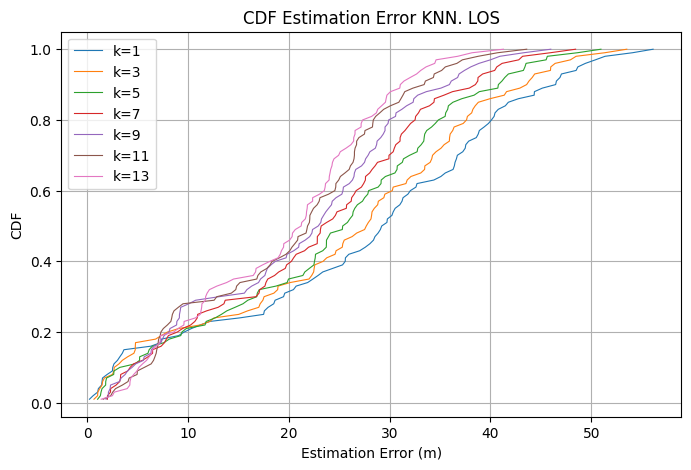

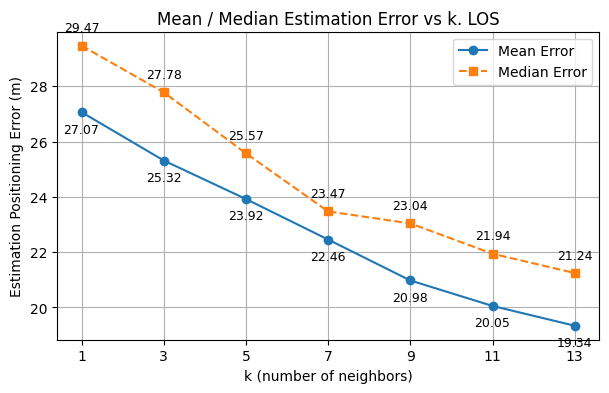

k=1: mean=27.07 m
k=3: mean=25.32 m
k=5: mean=23.92 m
k=7: mean=22.46 m
k=9: mean=20.98 m
k=11: mean=20.05 m
k=13: mean=19.34 m


In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

ks = [1, 3, 5, 7, 9, 11, 13]

# Normalización z-score filtrando features sin varianza
mu = np.mean(fingerprints_grid, axis=0)
sigma = np.std(fingerprints_grid, axis=0)
valid = sigma > 1e-10
print(f"Features válidas: {np.sum(valid)} de {len(sigma)}")

train_norm = (fingerprints_grid[:, valid] - mu[valid]) / sigma[valid]
test_norm = (fingerprints_test[:, valid] - mu[valid]) / sigma[valid]

# kNN
errores_por_k = {k: [] for k in ks}

for i in range(len(test_norm)):
    distancias = np.linalg.norm(train_norm - test_norm[i], axis=1)

    for k in ks:
        idx = np.argsort(distancias)[:k]
        pos_est = np.mean(positions_grid[idx], axis=0)
        error = np.linalg.norm(pos_est - positions_test[i])
        errores_por_k[k].append(error)

# Resultados
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))

# CDF
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.sort(errores_por_k[k])
    cdf = np.arange(1, len(errores)+1) / len(errores)
    plt.plot(errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. LOS")
plt.grid(True)
plt.legend()
plt.show()


# Mean/Median vs k
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s',
         linestyle='--', label="Median Error")

# Mean → abajo
for k, err in zip(ks, mean_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, -15),
        ha='center',
        fontsize=9
    )

# Median → arriba
for k, err in zip(ks, median_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9
    )

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. LOS")
plt.grid(True)
plt.legend()
plt.xticks(range(1,14,2))

plt.show()

for k, m in zip(ks, mean_errors):
    print(f"k={k}: mean={m:.2f} m")

MAXDEPTH 1

Features válidas: 10 de 10


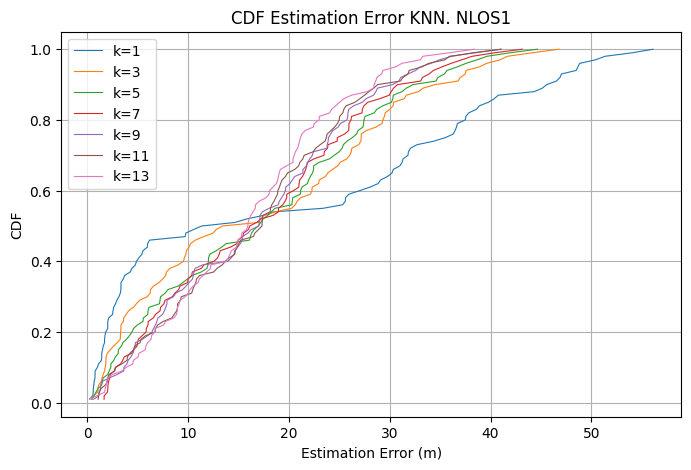

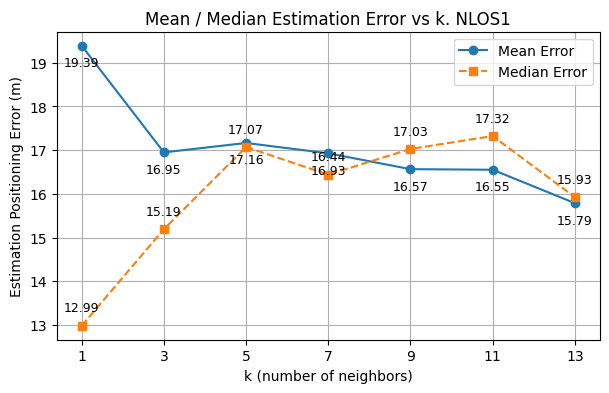

k=1: mean=19.39 m
k=3: mean=16.95 m
k=5: mean=17.16 m
k=7: mean=16.93 m
k=9: mean=16.57 m
k=11: mean=16.55 m
k=13: mean=15.79 m


In [26]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

ks = [1, 3, 5, 7, 9, 11, 13]

# Normalización z-score filtrando features sin varianza
mu = np.mean(fingerprints_grid, axis=0)
sigma = np.std(fingerprints_grid, axis=0)
valid = sigma > 1e-10
print(f"Features válidas: {np.sum(valid)} de {len(sigma)}")

train_norm = (fingerprints_grid[:, valid] - mu[valid]) / sigma[valid]
test_norm = (fingerprints_test[:, valid] - mu[valid]) / sigma[valid]

# kNN
errores_por_k = {k: [] for k in ks}

for i in range(len(test_norm)):
    distancias = np.linalg.norm(train_norm - test_norm[i], axis=1)

    for k in ks:
        idx = np.argsort(distancias)[:k]
        pos_est = np.mean(positions_grid[idx], axis=0)
        error = np.linalg.norm(pos_est - positions_test[i])
        errores_por_k[k].append(error)

# Resultados
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))

# CDF
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.sort(errores_por_k[k])
    cdf = np.arange(1, len(errores)+1) / len(errores)
    plt.plot(errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS1")
plt.grid(True)
plt.legend()
plt.show()


# Mean/Median vs k
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s',
         linestyle='--', label="Median Error")

# Mean → abajo
for k, err in zip(ks, mean_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, -15),
        ha='center',
        fontsize=9
    )

# Median → arriba
for k, err in zip(ks, median_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9
    )

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS1")
plt.grid(True)
plt.legend()
plt.xticks(range(1,14,2))

plt.show()

for k, m in zip(ks, mean_errors):
    print(f"k={k}: mean={m:.2f} m")

NLOS2

## 13. Position Estimation (Normalized kNN) & Results
Normalize features using z-score (filtering zero-variance features). Then apply kNN with Euclidean distance on the normalized space. Results shown as CDF and Mean/Median plots.

Features válidas: 10 de 10


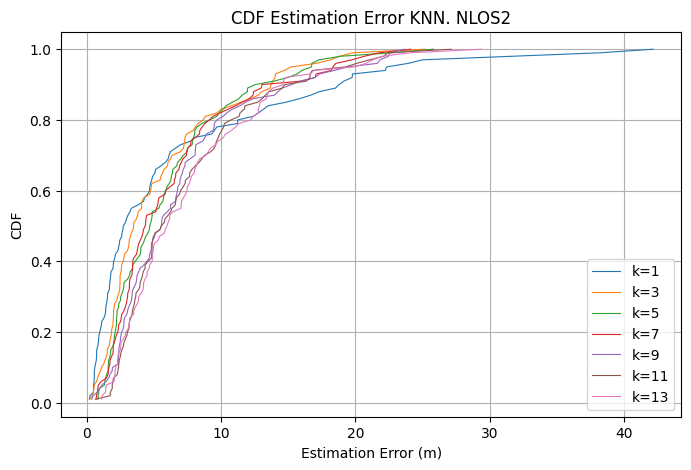

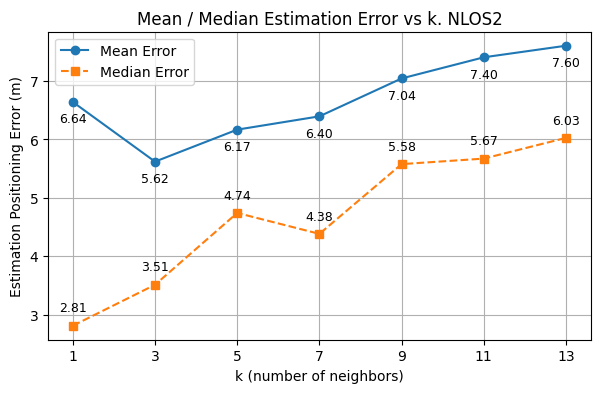

k=1: mean=6.64 m
k=3: mean=5.62 m
k=5: mean=6.17 m
k=7: mean=6.40 m
k=9: mean=7.04 m
k=11: mean=7.40 m
k=13: mean=7.60 m


In [36]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

ks = [1, 3, 5, 7, 9, 11, 13]

# Normalización z-score filtrando features sin varianza
mu = np.mean(fingerprints_grid, axis=0)
sigma = np.std(fingerprints_grid, axis=0)
valid = sigma > 1e-10
print(f"Features válidas: {np.sum(valid)} de {len(sigma)}")

train_norm = (fingerprints_grid[:, valid] - mu[valid]) / sigma[valid]
test_norm = (fingerprints_test[:, valid] - mu[valid]) / sigma[valid]

# kNN
errores_por_k = {k: [] for k in ks}

for i in range(len(test_norm)):
    distancias = np.linalg.norm(train_norm - test_norm[i], axis=1)

    for k in ks:
        idx = np.argsort(distancias)[:k]
        pos_est = np.mean(positions_grid[idx], axis=0)
        error = np.linalg.norm(pos_est - positions_test[i])
        errores_por_k[k].append(error)

# Resultados
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))

# CDF
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.sort(errores_por_k[k])
    cdf = np.arange(1, len(errores)+1) / len(errores)
    plt.plot(errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS2")
plt.grid(True)
plt.legend()
plt.show()


# Mean/Median vs k
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s',
         linestyle='--', label="Median Error")

# Mean → abajo
for k, err in zip(ks, mean_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, -15),
        ha='center',
        fontsize=9
    )

# Median → arriba
for k, err in zip(ks, median_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9
    )

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS2")
plt.grid(True)
plt.legend()
plt.xticks(range(1,14,2))

plt.show()

for k, m in zip(ks, mean_errors):
    print(f"k={k}: mean={m:.2f} m")

NLOS 6

Features válidas: 10 de 10


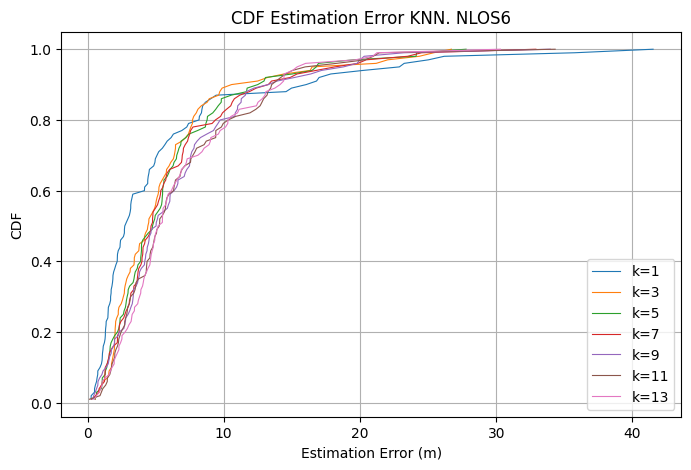

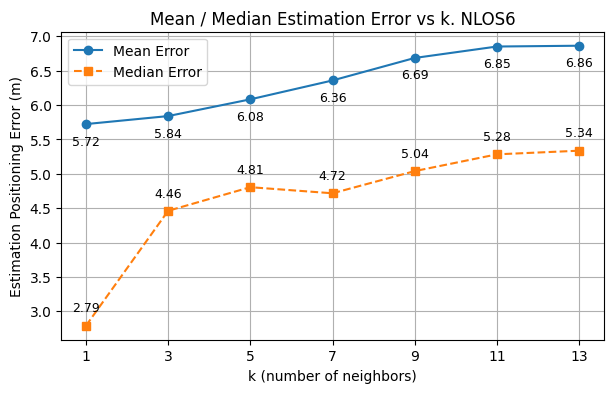

k=1: mean=5.72 m
k=3: mean=5.84 m
k=5: mean=6.08 m
k=7: mean=6.36 m
k=9: mean=6.69 m
k=11: mean=6.85 m
k=13: mean=6.86 m


In [46]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(123)

ks = [1, 3, 5, 7, 9, 11, 13]

# Normalización z-score filtrando features sin varianza
mu = np.mean(fingerprints_grid, axis=0)
sigma = np.std(fingerprints_grid, axis=0)
valid = sigma > 1e-10
print(f"Features válidas: {np.sum(valid)} de {len(sigma)}")

train_norm = (fingerprints_grid[:, valid] - mu[valid]) / sigma[valid]
test_norm = (fingerprints_test[:, valid] - mu[valid]) / sigma[valid]

# kNN
errores_por_k = {k: [] for k in ks}

for i in range(len(test_norm)):
    distancias = np.linalg.norm(train_norm - test_norm[i], axis=1)

    for k in ks:
        idx = np.argsort(distancias)[:k]
        pos_est = np.mean(positions_grid[idx], axis=0)
        error = np.linalg.norm(pos_est - positions_test[i])
        errores_por_k[k].append(error)

# Resultados
mean_errors = []
median_errors = []

for k in ks:
    errores = np.array(errores_por_k[k])
    mean_errors.append(np.mean(errores))
    median_errors.append(np.median(errores))

# CDF
plt.figure(figsize=(8,5))

for k in ks:
    errores = np.sort(errores_por_k[k])
    cdf = np.arange(1, len(errores)+1) / len(errores)
    plt.plot(errores, cdf, label=f'k={k}', linewidth=0.8)

plt.xlabel("Estimation Error (m)")
plt.ylabel("CDF")
plt.title("CDF Estimation Error KNN. NLOS6")
plt.grid(True)
plt.legend()
plt.show()


# Mean/Median vs k
plt.figure(figsize=(7,4))

plt.plot(ks, mean_errors, marker='o', label="Mean Error")
plt.plot(ks, median_errors, marker='s',
         linestyle='--', label="Median Error")

# Mean → abajo
for k, err in zip(ks, mean_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, -15),
        ha='center',
        fontsize=9
    )

# Median → arriba
for k, err in zip(ks, median_errors):
    plt.annotate(
        f"{err:.2f}",
        (k, err),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9
    )

plt.xlabel("k (number of neighbors)")
plt.ylabel("Estimation Positioning Error (m)")
plt.title("Mean / Median Estimation Error vs k. NLOS6")
plt.grid(True)
plt.legend()
plt.xticks(range(1,14,2))

plt.show()

for k, m in zip(ks, mean_errors):
    print(f"k={k}: mean={m:.2f} m")